# Analisis Sentimen Ulasan Produk Tokopedia 2025

Notebook ini mencakup pengambilan data, eksplorasi, preprocessing teks bahasa Indonesia, pelatihan Logistic Regression, evaluasi, dan prediksi sentimen.

## 1. Persiapan lingkungan

In [1]:
%pip install -q kagglehub Sastrawi wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.5 MB/s eta 0:00:00


In [2]:
import re
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from wordcloud import WordCloud

RANDOM_STATE = 42
LABELS = ["negative", "neutral", "positive"]
sns.set_theme(style="whitegrid")

## 2. Memuat dataset

In [3]:
dataset_dir = Path(kagglehub.dataset_download("salmanabdu/tokopedia-product-reviews-2025"))
csv_path = next(dataset_dir.glob("*.csv"))
df = pd.read_csv(csv_path)

print(f"Dataset: {csv_path.name}")
print(f"Ukuran: {df.shape[0]:,} baris × {df.shape[1]} kolom")
display(df.head())

100%|██████████| 3.54M/3.54M [00:00<00:00, 28.1MB/s]

Extracting files...


Dataset: tokopedia_product_reviews_2025.csv
Ukuran: 65,543 baris × 13 kolom


,review_text,review_date,review_id,product_name,product_category,product_variant,product_price,product_url,product_id,rating,sold_count,shop_id,sentiment_label
0,baru sekali ini terima brg dr belanja online d...,2024-12-22,1134256160,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
1,cocok bgt aku sama telur nya. nga Amis menurut...,2025-02-25,1242584634,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
2,Telornya sudah sampai di rumah dengan kemasan ...,2025-07-15,1573444677,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
3,Telor sudah diterima dengan baik dan tidak ada...,2025-07-20,1581728541,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
4,"Alhamdulillah penjual amanah,Telor nya terbaik...",2023-04-24,881041355,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Full Design,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive


## 3. Exploratory Data Analysis (EDA)

In [4]:
df.info()
display(df.describe(include="all"))
display(df.isna().sum().rename("missing_values"))
display(df["rating"].value_counts().sort_index().rename("jumlah"))
display(df["sentiment_label"].value_counts().rename("jumlah"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65543 entries, 0 to 65542
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   review_text       65543 non-null  object
 1   review_date       65543 non-null  object
 2   review_id         65543 non-null  int64 
 3   product_name      65543 non-null  object
 4   product_category  65543 non-null  object
 5   product_variant   26749 non-null  object
 6   product_price     65543 non-null  int64 
 7   product_url       65543 non-null  object
 8   product_id        65543 non-null  int64 
 9   rating            65543 non-null  int64 
 10  sold_count        65543 non-null  int64 
 11  shop_id           65543 non-null  int64 
 12  sentiment_label   65543 non-null  object
dtypes: int64(6), object(7)
memory usage: 6.5+ MB


,review_text,review_date,review_id,product_name,product_category,product_variant,product_price,product_url,product_id,rating,sold_count,shop_id,sentiment_label
count,65543,65543,6.554300e+04,65543,65543,26749,6.554300e+04,65543,6.554300e+04,65543.000000,65543.000000,6.554300e+04,65543
unique,58068,2845,NaN,5418,6,5511,NaN,5521,NaN,NaN,NaN,NaN,3
top,Bagus,2024-10-03,NaN,Chosamon Mid Top Original Sepatu Sneakers Olah...,Makanan & Minuman,Default,NaN,https://www.tokopedia.com/indofarmproduct/telu...,NaN,NaN,NaN,NaN,positive
freq,323,83,NaN,80,17859,1733,NaN,20,NaN,NaN,NaN,NaN,63943
mean,NaN,NaN,9.814143e+08,NaN,NaN,NaN,5.421295e+05,NaN,2.447482e+10,4.893764,1954.923897,7.615674e+16,NaN
std,NaN,NaN,4.193324e+08,NaN,NaN,NaN,2.365557e+06,NaN,3.870717e+10,0.492495,18244.026827,7.516573e+17,NaN
min,NaN,NaN,1.027202e+07,NaN,NaN,NaN,1.000000e+02,NaN,4.298375e+06,1.000000,6.000000,6.050000e+02,NaN
25%,NaN,NaN,7.182240e+08,NaN,NaN,NaN,2.990000e+04,NaN,1.446882e+09,5.000000,100.000000,2.298522e+06,NaN
50%,NaN,NaN,9.740048e+08,NaN,NaN,NaN,8.000000e+04,NaN,4.769575e+09,5.000000,500.000000,5.801280e+06,NaN
75%,NaN,NaN,1.145967e+09,NaN,NaN,NaN,2.146870e+05,NaN,1.534605e+10,5.000000,1000.000000,9.061811e+06,NaN


,missing_values
review_text,0
review_date,0
review_id,0
product_name,0
product_category,0
product_variant,38794
product_price,0
product_url,0
product_id,0
rating,0


,jumlah
rating,
1,547
2,251
3,802
4,2418
5,61525


,jumlah
sentiment_label,
positive,63943
neutral,802
negative,798


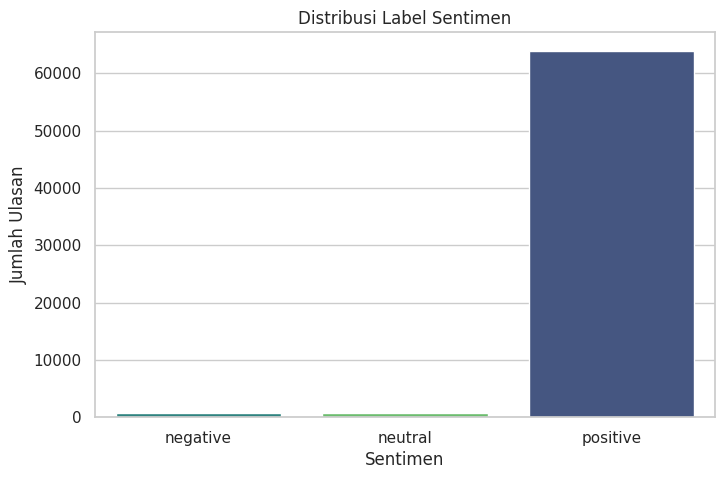

In [5]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="sentiment_label",
    order=LABELS,
    hue="sentiment_label",
    palette="viridis",
    legend=False,
)
plt.title("Distribusi Label Sentimen")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Ulasan")
plt.show()

## 4. Preprocessing teks

In [6]:
stopword_remover = StopWordRemoverFactory().create_stop_word_remover()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return stopword_remover.remove(text)

sample_text = df["review_text"].dropna().iloc[0]
print("Sebelum:", sample_text)
print("Sesudah:", clean_text(sample_text))

Sebelum: baru sekali ini terima brg dr belanja online dg packing super rapih dan aman. semula ragu, bagaimana mungkin mmbeli terlur ayam mentah , sec online. tp ternyata packing liar biasa. rapi, aman. Kerem seller
Sesudah: baru sekali terima brg dr belanja online dg packing super rapih aman semula ragu bagaimana mungkin mmbeli terlur ayam mentah sec online tp ternyata packing liar biasa rapi aman kerem seller


In [11]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Inisialisasi Stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def clean_text_advanced(text):
    # 1. Gunakan fungsi dasar yang sudah ada
    text = clean_text(text)
    # 2. Tambahkan Stemming (proses ini mungkin agak lambat untuk dataset besar)
    return stemmer.stem(text)

# Uji coba pada sample
print(f"Sebelum Stemming: {sample_text[:50]}...")
print(f"Sesudah Stemming: {clean_text_advanced(sample_text)}")

Sebelum Stemming: baru sekali ini terima brg dr belanja online dg pa...
Sesudah Stemming: baru sekali terima brg dr belanja online dg packing super rapih aman mula ragu bagaimana mungkin mmbeli terlur ayam mentah sec online tp nyata packing liar biasa rapi aman rem seller


In [12]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# Update pembersihan teks pada data balanced
df_balanced['clean_text'] = df_balanced['review_text'].apply(clean_text_advanced)

X_train, X_test, y_train, y_test = train_test_split(
    df_balanced['clean_text'],
    df_balanced['sentiment_label'],
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df_balanced['sentiment_label']
)

# Membuat Pipeline untuk mencari kombinasi terbaik
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

# Daftar parameter yang akan diuji
param_grid = {
    'tfidf__max_features': [1000, 2000, 3000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'clf__C': [0.1, 1, 10]
}

# Pencarian otomatis
grid_search = GridSearchCV(pipeline, param_grid, cv=5, n_jobs=-1, scoring='f1_macro')
grid_search.fit(X_train, y_train)

print(f"Parameter Terbaik: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")

Parameter Terbaik: {'clf__C': 1, 'tfidf__max_features': 3000, 'tfidf__ngram_range': (1, 1)}
Best CV Score: 0.6565


In [13]:
# Evaluasi hasil tuning
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

print("--- Hasil Setelah Tuning ---")
print(classification_report(y_test, y_pred_tuned, labels=LABELS))

--- Hasil Setelah Tuning ---
              precision    recall  f1-score   support

    negative       0.59      0.60      0.60       140
     neutral       0.54      0.51      0.52       140
    positive       0.80      0.84      0.82       140

    accuracy                           0.65       420
   macro avg       0.64      0.65      0.65       420
weighted avg       0.64      0.65      0.65       420



## 5. Pelatihan model

In [7]:
n_samples = 700
balanced_parts = []

for label in LABELS:
    group = df[df["sentiment_label"] == label]
    balanced_parts.append(
        group.sample(
            n=n_samples,
            replace=len(group) < n_samples,
            random_state=RANDOM_STATE,
        )
    )

df_balanced = pd.concat(balanced_parts, ignore_index=True)
df_balanced["clean_text"] = df_balanced["review_text"].apply(clean_text)

X_train, X_test, y_train, y_test = train_test_split(
    df_balanced["clean_text"],
    df_balanced["sentiment_label"],
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df_balanced["sentiment_label"],
)

tfidf = TfidfVectorizer(max_features=2_000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

model = LogisticRegression(max_iter=1_000, random_state=RANDOM_STATE)
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=42)

## 6. Evaluasi model

              precision    recall  f1-score   support

    negative       0.61      0.61      0.61       140
     neutral       0.54      0.53      0.53       140
    positive       0.82      0.83      0.83       140

    accuracy                           0.66       420
   macro avg       0.66      0.66      0.66       420
weighted avg       0.66      0.66      0.66       420



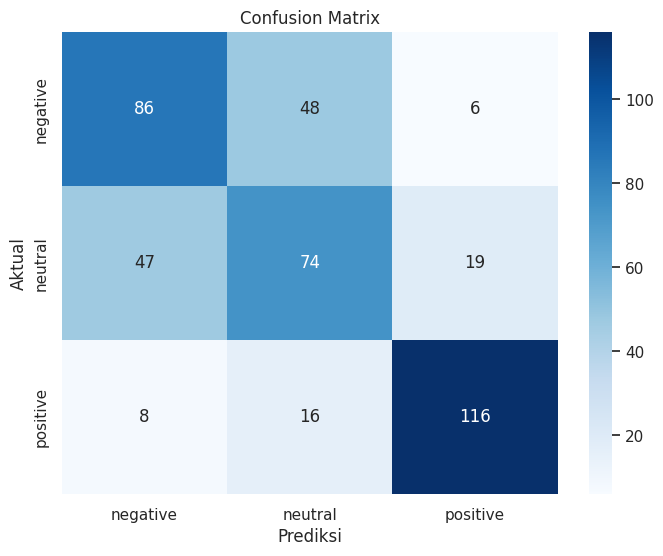

In [8]:
y_pred = model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred, labels=LABELS, zero_division=0))

cm = confusion_matrix(y_test, y_pred, labels=LABELS)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=LABELS,
    yticklabels=LABELS,
)
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix")
plt.show()

## 7. Visualisasi kata dominan

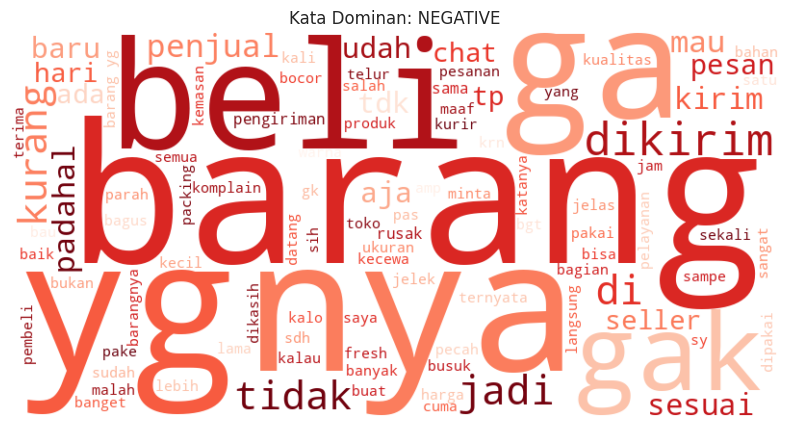

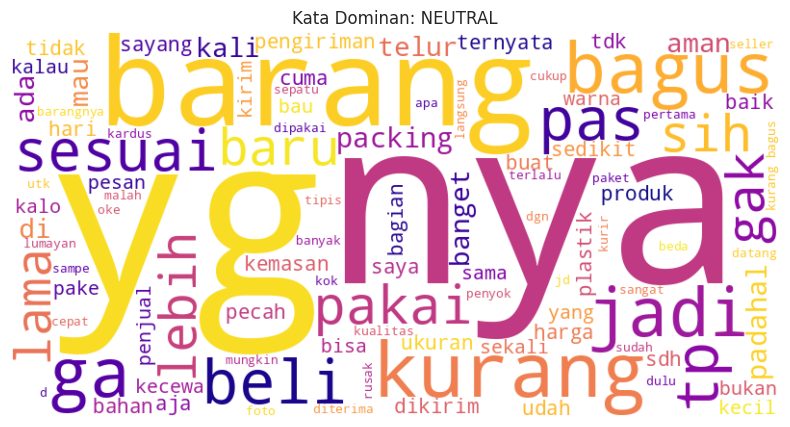

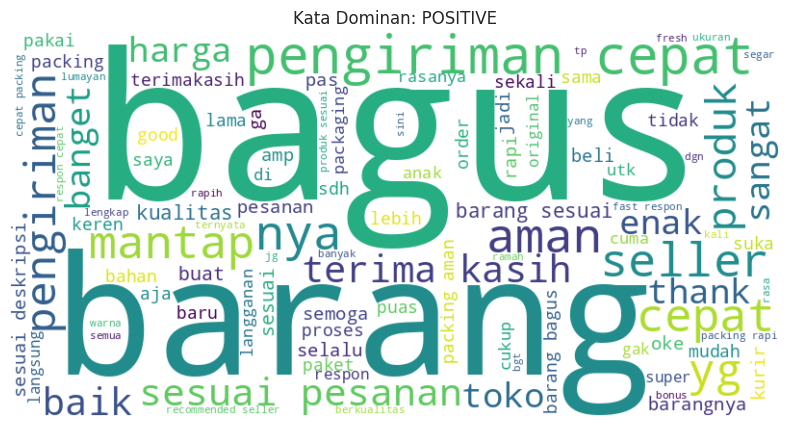

In [9]:
def show_wordcloud(sentiment, colormap):
    text = " ".join(
        df_balanced.loc[
            df_balanced["sentiment_label"] == sentiment, "clean_text"
        ]
    )
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white",
        colormap=colormap,
        max_words=100,
    ).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Kata Dominan: {sentiment.upper()}")
    plt.show()

for sentiment, colormap in zip(LABELS, ["Reds", "plasma", "viridis"]):
    show_wordcloud(sentiment, colormap)

## 8. Prediksi ulasan baru

In [10]:
def prediksi_sentimen(teks):
    teks_bersih = clean_text(teks)
    vektor = tfidf.transform([teks_bersih])
    return model.predict(vektor)[0]

contoh_ulasan = [
    "Barangnya rusak saat sampai",
    "Bagus banget, pengiriman cepat",
    "Biasa saja, lumayan",
]

for ulasan in contoh_ulasan:
    print(f"{ulasan!r}: {prediksi_sentimen(ulasan)}")

'Barangnya rusak saat sampai': negative
'Bagus banget, pengiriman cepat': positive
'Biasa saja, lumayan': neutral
